# BLOCO DE MARLIM
Comparação das predições (`PREDICTIONS`) com a anotação do especialista na inline
central do patch. Fluxo: `Generator2.ipynb` → `../Dataset/marlim_opt/Format.ipynb`
→ treino (`../Model/Analysis.ipynb`) → `Predict.ipynb` → comparação aqui.

`FaultComparer` é a classe única de comparação: reconstrói os tiles preditos,
extrai sticks retos (`FaultStickExtractor`), plota (`show`, com `save=` para
guardar a figura) e mede a convergência com o especialista (`metrics`).


In [1]:
import os, re, json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from PIL import Image
import scipy.ndimage as ndi
from tqdm import tqdm
from skimage.morphology import skeletonize


In [2]:
PATCH_METADATA = 'files/patch_metadata.json'
CACHE_DIR      = 'files/cache'
MARLIM_DIR     = '../Dataset/marlim'
FIGURES_DIR    = 'files/comparisons'


In [3]:
def gauss(img, sigma, sigma_x=None):
    return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma if sigma_x is None else sigma_x, sigmaY=sigma, borderType=cv2.BORDER_REFLECT)


def rotate(img, angle):
    h, w = img.shape
    M = cv2.getRotationMatrix2D(((w - 1) / 2, (h - 1) / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)


# EXTRAÇÃO DE STICKS
`FaultStickExtractor` converte um mapa de probabilidade (z, x) em falhas retas
estilo especialista. A `tolerance` (0 = conservador, 1 = permissivo) interpola
todos os hiperparâmetros internos.


In [4]:
class FaultStickExtractor:
    def __init__(self, tolerance=0.5, **kw):
        t = float(np.clip(tolerance, 0.0, 1.0))
        self.tolerance = t
        L = lambda a, b: a + (b - a) * t

        self.linenessThr     = L(0.40, 0.29)
        self.dipMin          = L(42, 36)
        self.minStickLen     = L(170, 110)
        self.minFill         = L(0.50, 0.34)
        self.hardLen         = L(85, 50)
        self.shortFill       = L(0.71, 0.50)
        self.mergeGap        = L(50, 80)
        self.thrShift        = L(+0.04, -0.06)

        self.thrClean        = 0.34
        self.thrDense        = 0.56
        self.densSigma       = 50
        self.densRef         = 0.25
        self.seedBoost       = 0.06

        self.energyMin       = 0.28
        self.energySigma     = 25

        self.dipMax          = 82
        self.growSkip        = 2
        self.lowDip          = 48
        self.lowDipFillExtra = 0.08
        self.angleStep       = 7
        self.lineLen         = 35
        self.lineWidth       = 1.5
        self.minSegLen       = 35
        self.minLinearity    = 0.88
        self.growStep        = 10
        self.growWidth       = 3.0
        self.growFill        = 0.30
        self.mergeAngle      = 11.0
        self.mergeOffset     = 9.0

        for k, v in kw.items():
            setattr(self, k, v)

    @staticmethod
    def _fit(ys, xs):
        pts    = np.stack([xs, ys]).astype(float)
        center = pts.mean(axis=1, keepdims=True)
        pts0   = pts - center

        w, v = np.linalg.eigh(pts0 @ pts0.T / pts.shape[1])
        d = v[:, -1]
        if d[1] < 0:
            d = -d

        linearity = w[-1] / (w.sum() + 1e-9)
        t   = d @ pts0
        dip = np.degrees(np.arctan2(abs(d[1]), abs(d[0]) + 1e-12))
        p0  = center[:, 0] + d * t.min()
        p1  = center[:, 0] + d * t.max()
        return p0, p1, dip, linearity, float(t.max() - t.min())

    def _corridorFill(self, supp, c, d, t0, t1):
        ts   = np.linspace(t0, t1, max(int(abs(t1 - t0)), 1))
        offs = np.arange(-self.growWidth, self.growWidth + 0.5)
        nvec = np.array([-d[1], d[0]])
        xs   = (c[0] + ts[:, None] * d[0] + offs[None, :] * nvec[0]).round().astype(int)
        ys   = (c[1] + ts[:, None] * d[1] + offs[None, :] * nvec[1]).round().astype(int)
        ok   = (ys >= 0) & (ys < supp.shape[0]) & (xs >= 0) & (xs < supp.shape[1])

        if not ok.any():
            return 0.0

        vals     = np.zeros(xs.shape, np.float32)
        vals[ok] = supp[ys[ok], xs[ok]]
        return float(vals.max(axis=1).mean())

    def threshold_map(self, p):
        dens = gauss((p > 0.30).astype(np.float32), self.densSigma)
        w    = np.clip(dens / self.densRef, 0, 1)
        return (self.thrClean + (self.thrDense - self.thrClean) * w + self.thrShift).astype(np.float32)

    def energy_map(self, seismic):
        sec = seismic.astype(np.float32)
        mu  = gauss(sec, self.energySigma)
        var = gauss(sec * sec, self.energySigma) - mu * mu
        E   = np.sqrt(np.clip(var, 0, None))
        return np.clip(E / (np.percentile(E, 95) + 1e-9), 0, 1).astype(np.float32)

    def lineness(self, pbin):
        sig_long = self.lineLen / 4.0
        best     = np.zeros_like(pbin)

        for ang in np.arange(self.dipMin, self.dipMax + 0.1, self.angleStep):
            for sgn in (1, -1):
                a = sgn * (90 - ang)
                r = rotate(gauss(rotate(pbin, a), sig_long, self.lineWidth), -a)
                np.maximum(best, r, out=best)

        resp = best - gauss(pbin, np.sqrt(sig_long * self.lineWidth))
        return np.clip(resp / (np.percentile(resp, 99.7) + 1e-9), 0, 1.5)

    def _split(self, ys, xs, depth=0):
        p0, p1, dip, lin, Ln = self._fit(ys, xs)
        if lin >= self.minLinearity or depth >= 4 or len(ys) < 2 * self.minSegLen:
            return [(ys, xs)]

        vx, vy = p1[0] - p0[0], p1[1] - p0[1]
        dist   = np.abs(vy * (xs - p0[0]) - vx * (ys - p0[1])) / (np.hypot(vx, vy) + 1e-9)
        m1     = ys <= ys[int(np.argmax(dist))]
        out    = []

        for m in (m1, ~m1):
            if m.sum() >= self.minSegLen:
                out += self._split(ys[m], xs[m], depth + 1)
        return out or [(ys, xs)]

    def segments(self, binary):
        lbl, n = ndi.label(skeletonize(binary), structure=np.ones((3, 3)))
        segs   = []

        for i, sl in enumerate(ndi.find_objects(lbl), 1):
            if sl is None:
                continue
            ys, xs = np.nonzero(lbl[sl] == i)
            if len(ys) < self.minSegLen:
                continue

            ys, xs = ys + sl[0].start, xs + sl[1].start
            for ys2, xs2 in self._split(ys, xs):
                p0, p1, dip, lin, Ln = self._fit(ys2, xs2)
                if Ln >= self.minSegLen and lin >= self.minLinearity and self.dipMin - 4 <= dip <= self.dipMax:
                    segs.append({'p0': p0, 'p1': p1, 'dip': dip, 'len': Ln})
        return segs

    def _grow_dir(self, supp, c, d, t, sgn):
        skips_left = self.growSkip

        for _ in range(300):
            step = sgn * self.growStep
            fill = self._corridorFill(supp, c, d, min(t, t + step), max(t, t + step))
            if fill >= self.growFill:
                t += step
                continue

            if skips_left > 0:
                fill2 = self._corridorFill(supp, c, d, min(t + step, t + 2 * step), max(t + step, t + 2 * step))
                if fill2 >= self.growFill:
                    t += 2 * step
                    skips_left -= 1
                    continue
            break
        return t

    def grow(self, seg, supp):
        p0, p1 = np.array(seg['p0']), np.array(seg['p1'])
        d  = p1 - p0
        Ln = np.linalg.norm(d) + 1e-9
        d, c = d / Ln, (p0 + p1) / 2

        tmax = self._grow_dir(supp, c, d, Ln / 2, +1)
        tmin = self._grow_dir(supp, c, d, -Ln / 2, -1)

        seg = dict(seg)
        seg['p0'], seg['p1'] = tuple(c + tmin * d), tuple(c + tmax * d)
        seg['len']  = float(tmax - tmin)
        seg['fill'] = self._corridorFill(supp, c, d, tmin, tmax)
        return seg

    def _collinear(self, a, b):
        da = np.array(a['p1']) - np.array(a['p0'])
        db = np.array(b['p1']) - np.array(b['p0'])
        da /= np.linalg.norm(da) + 1e-9
        db /= np.linalg.norm(db) + 1e-9

        if np.degrees(np.arccos(np.clip(abs(float(da @ db)), 0, 1))) > self.mergeAngle:
            return False

        ea  = [np.array(a['p0']), np.array(a['p1'])]
        eb  = [np.array(b['p0']), np.array(b['p1'])]
        gap = min(np.linalg.norm(x - y) for x in ea for y in eb)
        cb  = (eb[0] + eb[1]) / 2
        off = abs(da[1] * (cb[0] - a['p0'][0]) - da[0] * (cb[1] - a['p0'][1]))
        return (gap <= self.mergeGap) and (off <= self.mergeOffset)

    def merge(self, segs):
        parent = list(range(len(segs)))

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        for i in range(len(segs)):
            for j in range(i + 1, len(segs)):
                if self._collinear(segs[i], segs[j]):
                    parent[find(i)] = find(j)

        groups = {}
        for i in range(len(segs)):
            groups.setdefault(find(i), []).append(i)

        out = []
        for idx in groups.values():
            pts = np.array([segs[i]['p0'] for i in idx] + [segs[i]['p1'] for i in idx])
            p0, p1, dip, lin, Ln = self._fit(pts[:, 1], pts[:, 0])
            out.append({'p0': tuple(p0), 'p1': tuple(p1), 'dip': dip, 'len': Ln})
        return out

    def _dedup(self, sticks):
        keep, used = [], [False] * len(sticks)

        for i in np.argsort([-s['fill'] * s['len'] for s in sticks]):
            if used[i]:
                continue
            used[i] = True
            keep.append(sticks[i])

            for j in range(len(sticks)):
                if used[j] or not self._collinear(sticks[i], sticks[j]):
                    continue
                ci = (np.array(sticks[i]['p0']) + np.array(sticks[i]['p1'])) / 2
                cj = (np.array(sticks[j]['p0']) + np.array(sticks[j]['p1'])) / 2
                if np.linalg.norm(ci - cj) < (sticks[i]['len'] + sticks[j]['len']) / 4:
                    used[j] = True
        return keep

    def _stick_energy(self, s, energy):
        p0, p1 = np.array(s['p0']), np.array(s['p1'])
        d  = p1 - p0
        Ln = np.linalg.norm(d) + 1e-9
        return self._corridorFill(energy, (p0 + p1) / 2, d / Ln, -Ln / 2, Ln / 2)

    def _accept(self, s, energy):
        if not (self.dipMin <= s['dip'] <= self.dipMax) or s['len'] < self.hardLen:
            return False

        needE = (s['len'] < self.minStickLen) or (s['dip'] < self.lowDip)
        if needE and energy is not None:
            s['energy'] = round(self._stick_energy(s, energy), 3)
            if s['energy'] < self.energyMin:
                return False

        req = self.minFill if s['len'] >= self.minStickLen else self.shortFill
        if s['dip'] < self.lowDip:
            req += self.lowDipFillExtra
        return s['fill'] >= req

    def extract(self, prob, seismic=None):
        p      = gauss(prob.astype(np.float32), 1.0)
        thr    = self.threshold_map(p)
        seed   = (p > thr + self.seedBoost).astype(np.float32)
        growMap = (p > thr).astype(np.float32)
        energy = self.energy_map(seismic) if seismic is not None else None

        binary = (self.lineness(seed) > self.linenessThr) & ndi.binary_dilation(seed > 0, iterations=3)
        segs   = self.merge([self.grow(s, growMap) for s in self.segments(binary)])

        sticks = []
        for s in segs:
            s = self.grow(s, growMap)
            if self._accept(s, energy):
                sticks.append(s)
        return self._dedup(sticks)

    def extract_volume(self, vol, axis=0, step=4):
        return {i: self.extract(np.take(vol, i, axis=axis)) for i in tqdm(range(0, vol.shape[axis], step), desc='sticks')}

    @staticmethod
    def rasterize(sticks, shape, thickness=2):
        canvas = np.zeros(shape, np.uint8)

        for s in sticks:
            x0, y0 = s['p0']; x1, y1 = s['p1']
            n  = int(max(abs(x1 - x0), abs(y1 - y0)) * 2 + 1)
            xs = np.linspace(x0, x1, n).round().astype(int)
            ys = np.linspace(y0, y1, n).round().astype(int)
            ok = (ys >= 0) & (ys < shape[0]) & (xs >= 0) & (xs < shape[1])
            canvas[ys[ok], xs[ok]] = 1

        if thickness > 1:
            canvas = ndi.binary_dilation(canvas, iterations=thickness - 1).astype(np.uint8)
        return canvas


# COMPARAÇÃO DE FALHAS
`FaultComparer` recebe predições e compara na inline central. Suporta `show()`
com `showType='seismic'` (sísmica com predições), `showType='mask'` (máscara
sobre fundo preto) e `showType='both'` (sísmica sem predição ao lado da máscara)
para análise visual, e `metrics()` para convergência pixel/falha com o especialista.


In [5]:
class FaultComparer:
    def __init__(self, metadata_path=PATCH_METADATA, img=None, preds=None, tolerance=0.35, **extractor_kw):
        self.meta  = json.load(open(metadata_path))
        self.ps    = self.meta['patch_size']
        self.ov    = self.meta['overlap_voxels']
        self.shape = tuple(self.meta['original_shape'])

        self.img_path     = img
        self.preds        = [dict(p) for p in (preds or [])]
        self.tolerance    = tolerance
        self.extractor_kw = extractor_kw
        self._extractors, self._maps, self._sticks, self._bg = {}, {}, {}, None

    def _reconstruct(self, path, desc='montando'):
        ps, ov  = self.ps, self.ov
        stride  = ps - 2 * ov
        lastIdx = [n // stride for n in self.shape]
        vol     = np.zeros(self.shape, np.float32)

        for fname in tqdm(sorted(os.listdir(path)), desc=desc):
            m = re.match(r'patch_d(\d+)_h(\d+)_w(\d+)\.dat', fname)
            if not m:
                continue

            d, h, w = [max(0, size - stride) if idx == last else idx * stride
                       for idx, last, size in zip(map(int, m.groups()), lastIdx, self.shape)]

            core = np.fromfile(os.path.join(path, fname), np.float32).reshape((ps, ps, ps))
            core = core[ov:ps - ov, ov:ps - ov, ov:ps - ov]

            cd = min(core.shape[0], self.shape[0] - d)
            ch = min(core.shape[1], self.shape[1] - h)
            cw = min(core.shape[2], self.shape[2] - w)
            vol[d:d + cd, h:h + ch, w:w + cw] = core[:cd, :ch, :cw]
        return vol

    def _center_section(self, path, desc):
        vol = self._reconstruct(self._resolve_tiles(path), desc)
        sec = vol[vol.shape[0] // 2].copy()
        del vol
        return sec

    @staticmethod
    def _is_annotation(p):
        return str(p['path']).lower().endswith('.png')

    def _resolve_tiles(self, path):
        for sub in ('', 'masks', 'images', 'predictions'):
            d = os.path.join(path, sub)
            if os.path.isdir(d) and any(f.startswith('patch_d') and f.endswith('.dat') for f in os.listdir(d)):
                return d
        raise FileNotFoundError(f'nenhum patch_*.dat em {path}')

    def section(self, label):
        if label not in self._maps:
            p    = next(q for q in self.preds if q['label'] == label)
            path = str(p['path'])

            if path.endswith('.png'):
                sec = (np.array(Image.open(path).convert('L')) > 128).astype(np.float32)
            elif path.endswith('.npy'):
                sec = np.load(path).astype(np.float32)
            else:
                sec = self._center_section(path, p['label'])
            self._maps[label] = sec
        return self._maps[label]

    @property
    def background(self):
        if self._bg is None and self.img_path:
            pid = str(self.img_path).rstrip('/').split('_')[-1]
            os.makedirs(CACHE_DIR, exist_ok=True)
            cache = os.path.join(CACHE_DIR, f'real_center_{pid}.npy')

            if os.path.exists(cache):
                self._bg = np.load(cache)
            else:
                self._bg = self._center_section(self.img_path, 'bloco')
                np.save(cache, self._bg)
        return self._bg

    def extractor(self, tolerance=None):
        t = float(self.tolerance if tolerance is None else tolerance)
        if t not in self._extractors:
            self._extractors[t] = FaultStickExtractor(tolerance=t, **self.extractor_kw)
        return self._extractors[t]

    def sticks(self, label, tolerance=None):
        t   = float(self.tolerance if tolerance is None else tolerance)
        key = (label, t)
        if key not in self._sticks:
            self._sticks[key] = self.extractor(t).extract(self.section(label), seismic=self.background)
        return self._sticks[key]

    def show(self, force_linear=True, tolerance=None, threshold=0.5, alpha=1, showType='seismic', figsize=(15, 9), save=None):
        if showType == 'both':
            return self._showBoth(force_linear=force_linear, tolerance=tolerance, threshold=threshold, alpha=alpha, figsize=figsize, save=save)

        isMask = showType == 'mask'
        fig, ax = plt.subplots(figsize=figsize)
        bg = np.zeros(self.shape[1:]) if isMask else (self.background if self.background is not None else np.zeros(self.shape[1:]))
        ax.imshow(bg, cmap='gray', aspect='auto', zorder=0)
        self._drawPreds(ax, force_linear, tolerance, threshold, alpha, isMask)

        mode   = f'sticks (force_linear, tolerance={self.extractor(tolerance).tolerance})' if force_linear else f'threshold {threshold}'
        suffix = f' [{showType}]'
        ax.set_title(f'comparação de falhas — {mode}{suffix}')
        ax.legend(handles=self._buildHandles(), loc='upper right', framealpha=0.9)
        plt.tight_layout()

        if save:
            os.makedirs(os.path.dirname(save) or '.', exist_ok=True)
            plt.savefig(save, dpi=200, bbox_inches='tight')
            plt.close(fig)
            return print(f'figura salva em {save}')

        plt.show()

    def _drawPreds(self, ax, force_linear, tolerance, threshold, alpha, isMask):
        for i, p in enumerate(self.preds):
            color = to_rgb(p['color'])
            z     = 2 + i

            if self._is_annotation(p):
                gy, gx = np.where(self.section(p['label']) > 0.5)
                ax.scatter(gx, gy, s=0.05, c=[color], alpha=0.8, zorder=z)
            elif force_linear:
                for s in self.sticks(p['label'], tolerance):
                    ax.plot([s['p0'][0], s['p1'][0]], [s['p0'][1], s['p1'][1]], color=color, lw=1.6, zorder=z)
            else:
                m    = self.section(p['label']) >= threshold
                rgba = np.zeros((*m.shape, 4), np.float32)
                rgba[..., :3] = color
                rgba[..., 3]  = m * (1.0 if isMask else alpha)
                ax.imshow(rgba, aspect='auto', zorder=z)

    def _buildHandles(self):
        return [Patch(facecolor=to_rgb(p['color']), label=p['label']) for p in self.preds]

    def _showBoth(self, force_linear, tolerance, threshold, alpha, figsize, save):
        fig, (axSeismic, axMask) = plt.subplots(1, 2, figsize=(figsize[0] * 2, figsize[1]))

        bgSeismic = self.background if self.background is not None else np.zeros(self.shape[1:])
        axSeismic.imshow(bgSeismic, cmap='gray', aspect='auto', zorder=0)
        axSeismic.set_title('sísmica (sem predição)')

        bgMask = np.zeros(self.shape[1:])
        axMask.imshow(bgMask, cmap='gray', aspect='auto', zorder=0)
        self._drawPreds(axMask, force_linear, tolerance, threshold, alpha, isMask=True)
        mode = f'sticks (force_linear, tolerance={self.extractor(tolerance).tolerance})' if force_linear else f'threshold {threshold}'
        axMask.set_title(f'máscara — {mode}')
        axMask.legend(handles=self._buildHandles(), loc='upper right', framealpha=0.9)
        plt.tight_layout()

        if save:
            os.makedirs(os.path.dirname(save) or '.', exist_ok=True)
            plt.savefig(save, dpi=200, bbox_inches='tight')
            plt.close(fig)
            return print(f'figura salva em {save}')

        plt.show()

# TESTES NO BLOCO DE MARLIM


dataset mix (sintéticos grva + marlim: 100%|██████████| 910/910 [00:01<00:00, 765.01it/s]


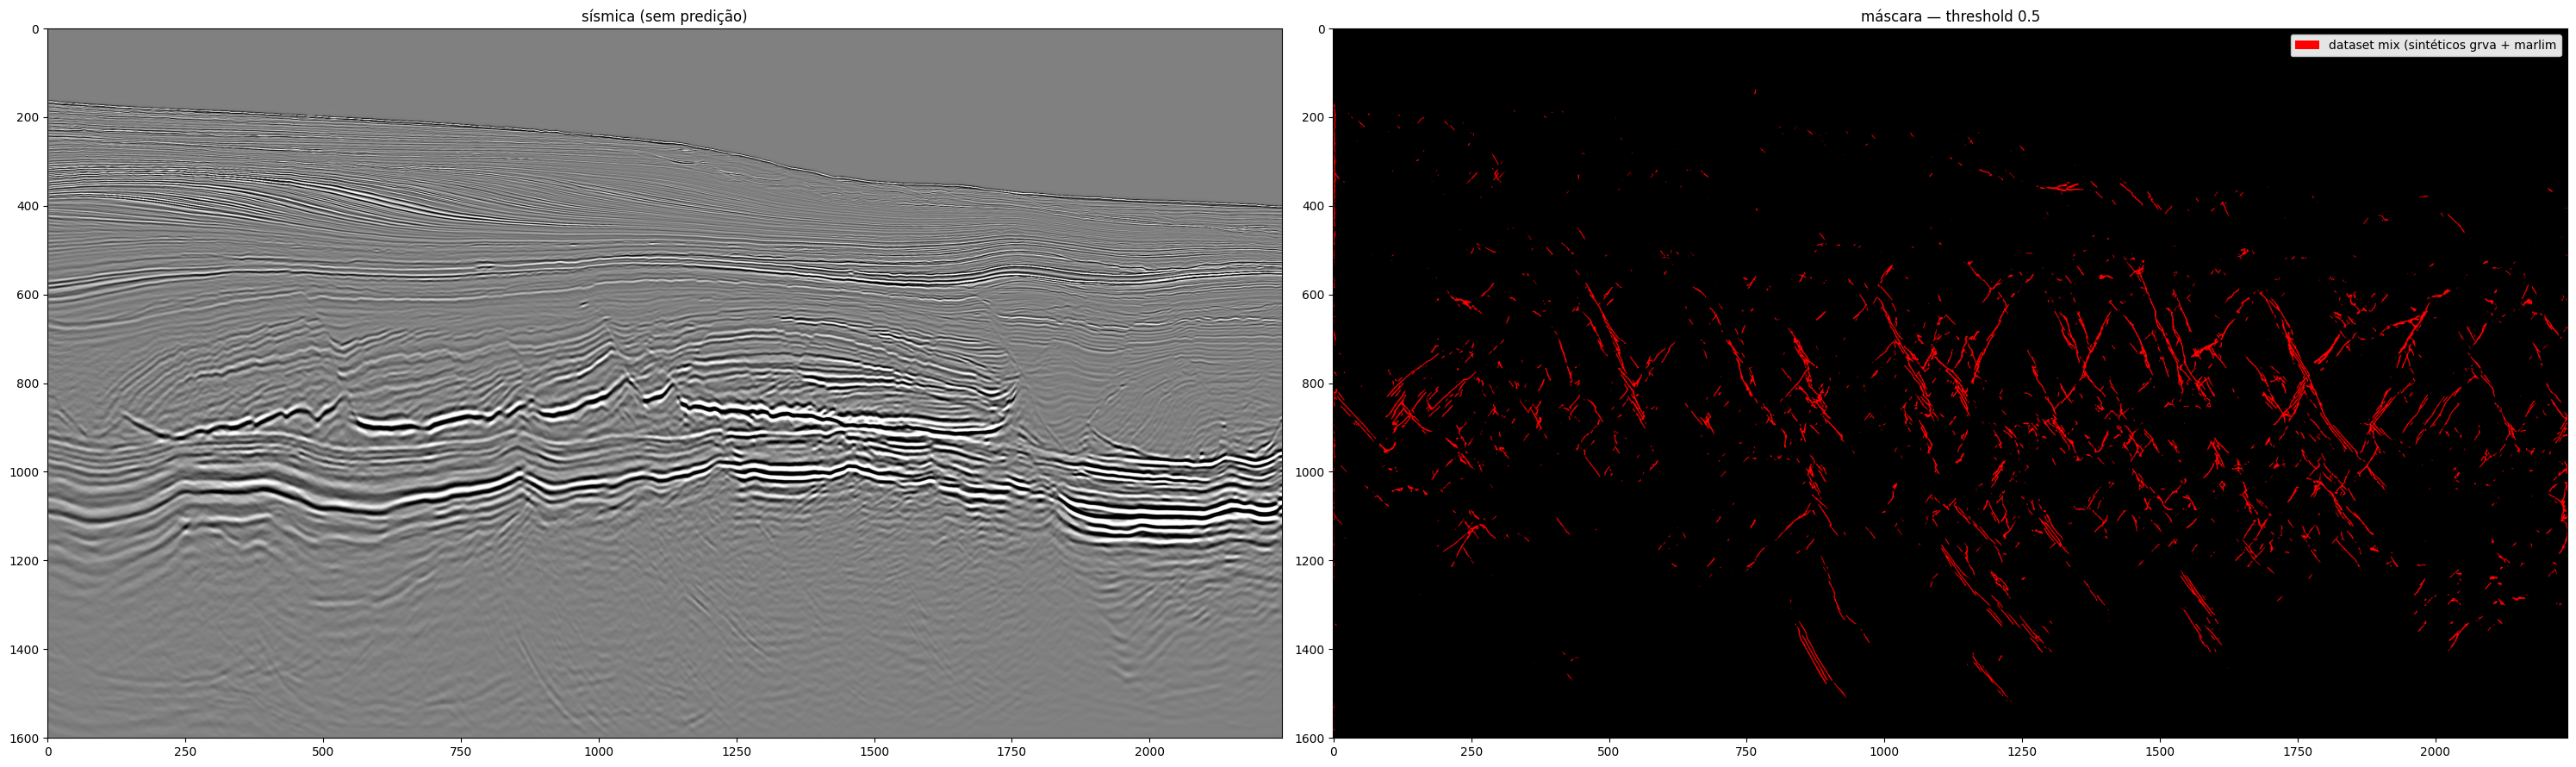

In [6]:
comparer = FaultComparer(img=f'{MARLIM_DIR}/patch_1200', preds=[
    {
        'path': '../Model/Backup/model_1/marlim/patch_1200/masks',
        'color': 'red',
        'label': 'dataset mix (sintéticos grva + marlim'
    }
])

comparer.show(force_linear=False, threshold=0.5, showType='both')

{'title': 'modelo unet tunada com dataset grva (74% dados do wu)', 'trainer': {'path': 'model_1', 'loss': 'dice_focal', 'scheduler': 'plateau', 'epochs': 100, 'batch_size': 2, 'val_iou': 0.720610499382019, 'test_iou': 0.7360016703605652}, 'processing': {'network': 'unet3d_v2', 'dataset': 'dataset_74', 'img_size': [128, 128, 128], 'lr': 0.001, 'loss': 'dice_focal', 'batch_size': 2, 'scheduler': 'plateau', 'dropout': 0.1, 'num_filters': 32, 'n_images': {'total': 220, 'train': 200, 'val': 10, 'test': 10}}, 'model': {'network': 'unet3d_v2', 'img_size': [128, 128, 128], 'classes': 1, 'channels': 1, 'dropout': 0.1, 'num_filters': 32, 'lr': 0.001}, 'iou': {'mean': 0.7360016703605652}}


modelo: modelo unet tunada com dataset grva (74% dados do wu): 100%|██████████| 910/910 [00:01<00:00, 782.07it/s]


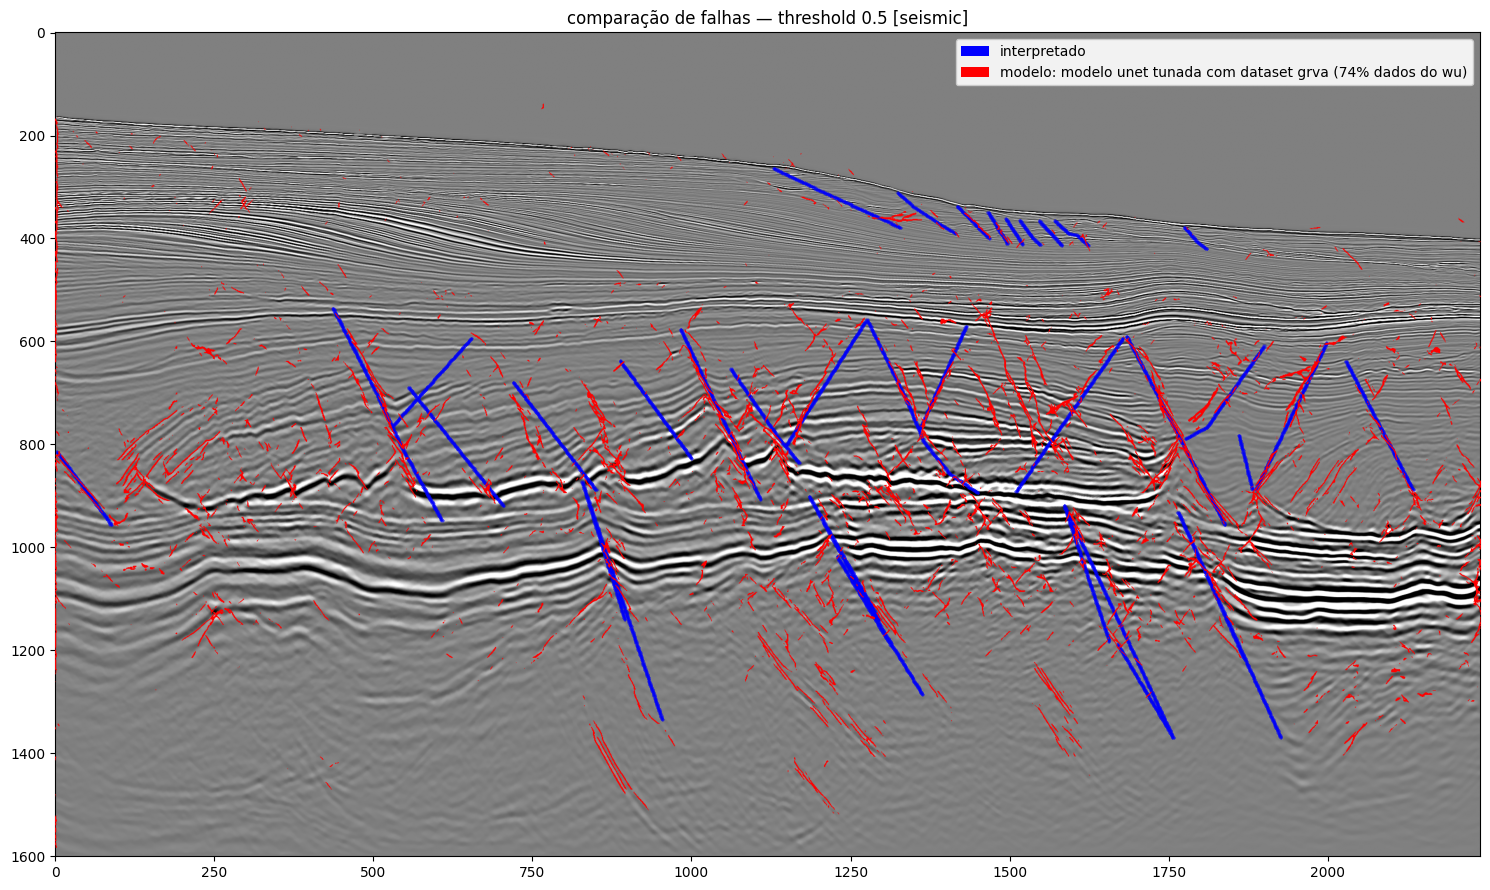

In [7]:
model_path = '../Model/Backup/model_1'
info = json.loads(open(f'{model_path}/info.json', 'r').read())
print(info)

comparer = FaultComparer(img=f'{MARLIM_DIR}/patch_1200', preds=[
    {
        'path': 'files/patches/1200/1200_interpretado.png',
        'color': 'blue',
        'label': 'interpretado'
    },
    {
        'path': f'{model_path}/marlim/patch_1200/masks',
        'color': 'red',
        'label': f'modelo: {info.get("title")}'
    },
])

comparer.show(force_linear=False, threshold=0.5, showType='seismic')

# RECONSTRUÇÃO DAS PREDIÇÕES
Varre todos os modelos em `../Model/Backup/` que possuem a pasta `marlim/`,
reconstrói o volume predito de cada patch a partir dos tiles `.dat` em `masks/`
e salva, no diretório `marlim/` do modelo, a máscara (`predicted_{patch}.npy`) e a
figura de comparação (`predicted_{patch}.png`: sísmica + interpretado + modelo).
A seção central do volume já reconstruído é reaproveitada na figura, então não há
segunda reconstrução.


In [8]:
BACKUP_DIR = '../Model/Backup'

for modelName in sorted(os.listdir(BACKUP_DIR)):
    modelPath = os.path.join(BACKUP_DIR, modelName)
    marlimDir = os.path.join(modelPath, 'marlim')

    if not os.path.isdir(marlimDir):
        continue

    infoPath = os.path.join(modelPath, 'info.json')
    info     = json.load(open(infoPath)) if os.path.exists(infoPath) else {}

    for patchName in sorted(os.listdir(marlimDir)):
        patchDir = os.path.join(marlimDir, patchName)

        if not os.path.isdir(patchDir):
            continue

        patchId    = patchName.replace('patch_', '')
        metaPath   = os.path.join(MARLIM_DIR, patchName, 'patch_metadata.json')
        annPath    = f'files/patches/{patchId}/{patchId}_interpretado.png'
        modelLabel = f'modelo: {info.get("title", modelName)}'
        preds      = []

        if os.path.exists(annPath):
            preds.append({'path': annPath, 'color': 'blue', 'label': 'interpretado'})

        preds.append({'path': patchDir, 'color': 'red', 'label': modelLabel})
        comparer = FaultComparer(metadata_path=metaPath, img=f'{MARLIM_DIR}/{patchName}', preds=preds)

        try:
            vol = comparer._reconstruct(comparer._resolve_tiles(patchDir), desc=f'{modelName}/patch_{patchId}')
        except FileNotFoundError:
            continue

        npyPath = os.path.join(marlimDir, f'predicted_{patchId}.npy')
        np.save(npyPath, vol)
        print(f'[{modelName}] {npyPath} — shape {vol.shape}')

        comparer._maps[modelLabel] = vol[vol.shape[0] // 2].copy()
        del vol

        pngPath = os.path.join(marlimDir, f'predicted_{patchId}.png')
        comparer.show(force_linear=False, threshold=0.5, showType='seismic', save=pngPath)

model_1/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 718.79it/s]


[model_1] ../Model/Backup/model_1/marlim/predicted_1200.npy — shape (64, 1601, 2240)
figura salva em ../Model/Backup/model_1/marlim/predicted_1200.png


model_2/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 706.45it/s]


[model_2] ../Model/Backup/model_2/marlim/predicted_1200.npy — shape (64, 1601, 2240)
figura salva em ../Model/Backup/model_2/marlim/predicted_1200.png


model_3/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 739.14it/s]


...

[model_4] ../Model/Backup/model_4/marlim/predicted_1200.npy — shape (64, 1601, 2240)
figura salva em ../Model/Backup/model_4/marlim/predicted_1200.png


model_5/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 709.52it/s]


[model_5] ../Model/Backup/model_5/marlim/predicted_1200.npy — shape (64, 1601, 2240)
figura salva em ../Model/Backup/model_5/marlim/predicted_1200.png


model_6/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 756.99it/s]


[model_6] ../Model/Backup/model_6/marlim/predicted_1200.npy — shape (64, 1601, 2240)
figura salva em ../Model/Backup/model_6/marlim/predicted_1200.png
